# Étape 2 — Analyse des sentiments des conversations

## Notebook annoté

Ce notebook implémente un **classificateur de sentiments** sur des textes liés à la santé mentale, en suivant deux approches complémentaires :
- **Méthode supervisée** : Naive Bayes
- **Méthode non-supervisée** : K-Means

Le corpus d'entraînement utilisé est le dataset *Sentiment Analysis for Mental Health* (`Combined Data.csv`) disponible sur Kaggle.

---

## 1. Initialisation

Cette cellule importe l'ensemble des bibliothèques nécessaires au notebook :

| Bibliothèque | Rôle |
|---|---|
| `numpy`, `pandas` | Manipulation de données et tableaux numériques |
| `matplotlib`, `seaborn` | Visualisation (graphiques, camemberts) |
| `re` | Expressions régulières pour le nettoyage du texte |
| `WordCloud` | Génération de nuages de mots |
| `Counter` | Comptage de fréquences d'éléments |
| `sklearn` | Modèles ML, vectorisation, métriques d'évaluation |
| `nltk` | Traitement du langage naturel (tokenisation, stop-words) |

In [3]:
# importing libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import nltk 
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

C:\Users\hahag\AppData\Local\Temp\ipykernel_11176\3897297463.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### 1.1 Chargement des données

Chargement du fichier `Combined Data.csv` dans un DataFrame pandas. Le paramètre `index_col=0` indique que la première colonne du CSV est l'index des lignes (et non une colonne de données à part entière). `df.head()` affiche les 5 premières lignes pour vérifier que le chargement s'est bien passé.

In [4]:
df=pd.read_csv("../../data/combined_data.csv",index_col=0)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


### 1.2 Mélange des données

Le dataset est **mélangé aléatoirement** (`sample(frac=1)`) avant tout traitement. Cela évite un biais si les données sont triées par ordre (ex : toutes les lignes d'une même classe regroupées). `random_state=42` garantit la **reproductibilité** : le même ordre sera obtenu à chaque exécution. `reset_index(drop=True)` remet les indices à 0, 1, 2… après le mélange.

In [5]:
# shuffle the rows, reset the indices
df = df.sample(frac = 1 ,random_state=42).reset_index(drop = True)
df

,statement,status
0,Just as the the title says. I feel like one is...,Depression
1,a blackened sky encroached tugging behind it m...,Depression
2,"It gives you insomnia, which in turn makes you...",Depression
3,"Hello all, I'm a new submitter to this channel...",Normal
4,Thank God the CB is over for Eid,Normal
...,...,...
53038,"I used to be a very confident, cheerful person...",Depression
53039,spanx except i missed last week s lee and now ...,Normal
53040,tl dr have been abused mentally and physically...,Depression
53041,do i sell the tutorial again?,Normal


### 1.3 Distribution des classes

`value_counts()` compte le nombre d'occurrences de chaque valeur unique dans la colonne `status` (les étiquettes de sentiment). Cette étape permet de vérifier si le dataset est **équilibré** ou non — un déséquilibre important entre classes peut impacter les performances des modèles.

In [6]:
# Count the occurrences of each status
label_counts = df['status'].value_counts()
print(label_counts)

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


## 1.4 Visualisation de la distribution (camembert)

Ce graphique en camembert représente visuellement la **distribution des classes** calculée à l'étape précédente. `autopct='%1.1f%%'` affiche le pourcentage de chaque classe avec une décimale. La palette `pastel` de seaborn donne des couleurs douces et distinctes.

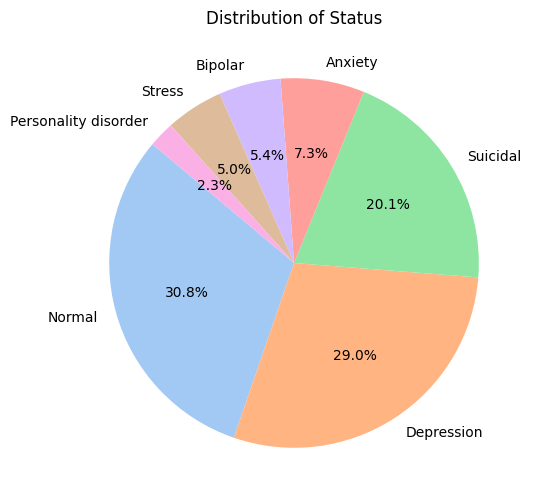

In [7]:
# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Status');

---
## 2. Nettoyage des données
### 2.1. Détection des valeurs manquantes

`isnull().sum()` compte le nombre de valeurs `NaN` (manquantes) dans chaque colonne. C'est une étape systématique de **contrôle qualité** : des valeurs manquantes dans la colonne `statement` provoqueraient des erreurs lors du nettoyage ou de la vectorisation.

In [8]:
# Missing values
df.isnull().sum()

statement    362
status         0
dtype: int64

### 2.2 Suppression des lignes vides

`dropna(axis=0)` supprime toutes les lignes contenant au moins une valeur manquante. Le paramètre `inplace=True` modifie directement le DataFrame sans créer une copie. Cette étape fait suite à la détection précédente.

In [9]:
# Drop rows with missing values
df.dropna(axis=0, inplace = True)
df.describe()

,statement,status
count,52681,52681
unique,51073,7
top,what do you mean?,Normal
freq,22,16343


### 2.3. Détection des étiquettes conflictuelles

Certains énoncés (`statement`) peuvent apparaître plusieurs fois dans le dataset avec des étiquettes (`status`) différentes — ce qui est contradictoire pour l'apprentissage. Cette cellule identifie ces cas en comptant le nombre de statuts distincts par énoncé. Si `nunique() != 1`, l'énoncé a plusieurs labels incompatibles.

In [10]:
# Count unique statuses for each statement
duplicate_labels = df.groupby('statement')['status'].nunique()

# Filter statements with more than one unique status
conflicting_statements = duplicate_labels[duplicate_labels != 1]

# Display problematic statements
print(f"Nombre de déclarations en conflit : {len(conflicting_statements)}")

Nombre de déclarations en conflit : 18


### 2.4 Suppression des étiquettes conflictuelles

On conserve uniquement les lignes dont l'énoncé possède **un seul statut cohérent** (`nunique() == 1`). Le `transform('nunique')` propage la valeur calculée par groupe à chaque ligne individuelle, ce qui permet le filtrage. `df.shape` est affiché pour confirmer la taille du dataset après nettoyage.

In [11]:
# Remove rows with confilicting labels, only keep statements that have a single consistent status
df = df[df.groupby('statement')['status'].transform('nunique') == 1]

print(df.shape)  # Check new dataset size

(52632, 2)


### 2.5. Nettoyage du texte (`cleaner`)

Cette fonction applique plusieurs **règles de nettoyage** via des expressions régulières :

| Règle | Exemple |
|---|---|
| Suppression des mentions `@utilisateur` | `@john` → supprimé |
| Suppression des URLs | `https://...` → supprimé |
| Suppression du HTML | `<br>`, `<b>` → supprimé |
| Détection des émoticônes textuels | `:)`, `;-P` → conservés en fin |
| Mise en minuscules + suppression des non-mots | `Hello!` → `hello` |

Les émoticônes sont extraits avant la suppression des non-mots, puis réajoutés à la fin du texte nettoyé.

In [ ]:
# Defining a text cleaner
import re
def cleaner(text):
    text = re.sub(r'\s*@\w+', '', text)                            # remove words starting with @ 
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)            # remove URLs 
    text = re.sub(r'<[^>]*>', '', text)                            # remove all of the HTML markup
    #text = re.sub(r'\b\w\b', '', text)                             # remove single letters, I, a, ...
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)  # find emoticons (emoji)
    text = (re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')) 
    #  replace any non_word with space, lowercase words, add emojis at the end
    return text

'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


### 2.6. Application du nettoyage

La fonction `cleaner` est appliquée à chaque ligne de la colonne `statement` via `.apply()`. `df.loc[:, 'statement']` est utilisé (plutôt que `df['statement']`) pour éviter un `SettingWithCopyWarning` de pandas lors de la modification en place. Le nombre de lignes restantes est affiché en sortie.

> **Note** : le bloc de détection de langue (`is_english`) est commenté. Il permettrait de ne conserver que les textes en anglais, mais alourdit le traitement. À réactiver si le corpus contient des textes multilingues.

In [ ]:
# Cleaning the text
from langdetect import detect
from langdetect import DetectorFactory
DetectorFactory.seed = 42
df.loc[:, 'statement'] = df['statement'].apply(cleaner)
#def is_english(text):
 #   try:
  #      return detect(str(text)) == 'en'
   # except:
    #    return False  # si détection échoue on supprime la ligne
print(f"Après filtres : {df.shape[0]} lignes")
#df['statement'].apply(is_english)
#print(f"Après filtres : {df.shape[0]} lignes")
#only english text in base documents

SyntaxError: invalid syntax (3541386947.py, line 2)

### 2.7 Vérification d'un exemple nettoyé

Affiche le contenu de la ligne d'index 10 après nettoyage, pour vérifier visuellement que la fonction `cleaner` produit bien le résultat attendu (minuscules, sans ponctuation ni URL).

In [ ]:
df['statement'][10]

'so i m sure all of you who live with anxiety do have your good day like the bad crippling anxiety come in wave which it doe for me when it s bad my anxiety is looking for any reason to latch it s self onto and make me believe that whatever the reason is that s what make me feel like shit when i have my good day and that thought or issue come to mind i m unfazed it s really fuckn annoying and i feel like it could make me make decision that i will for sure regret why is the brain so damn powerful and why do i have to live with this year of always feeling like shit it ha ruined my quality of life i am very grateful for my family and friend and i am grateful that i ve always had a good life but man i think of all the family trip event party anything fun ruined by my anxiety and sickness that come with it i feel for everyone that ha to go through this i m sorry guy and i hope one day we can be truly happy'

### 2.8 Séparation features / cible

On sépare le DataFrame en deux variables :
- `X` : les **features** (les énoncés textuels nettoyés, colonne `statement`)
- `y` : la **cible** (les étiquettes de sentiment, colonne `status`)

C'est la convention standard en scikit-learn avant tout découpage ou entraînement.

In [ ]:
# Assigning features and target
X = df['statement']
y = df['status']

---
## 3. Entrainement du modèle
### 3.1 Découpage Train / Validation / Test

Mais alors pourquoi séparer les donnée en 3 et non 2 ?
En effet, il est courant de diviser les données en trois ensembles :
- **Ensemble d'entraînement (Train)** : utilisé pour entraîner le modèle.
- **Ensemble de validation (Validation)** : utilisé pour ajuster les hyperparamètres du modèle et éviter le surapprentissage (overfitting).
- **Ensemble de test (Test)** : utilisé pour évaluer la performance finale du modèle sur des données qu'il n'a jamais vues auparavant.
Cela permet d'avoir une évaluation plus fiable de la performance du modèle, car le test est effectué sur des données totalement indépendantes de celles utilisées pour l'entraînement et la validation.

Le paramètre `stratify=y` garantit que la **proportion de chaque classe** est identique dans les trois ensembles — indispensable en cas de déséquilibre des classes. `random_state=42` assure la reproductibilité.

In [ ]:
# First split -> 60% train, 40% temp (validation + test)
# Second split -> 20% validation, 20% test (from the 40% temp)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")

Train : 31579 | Val : 10526 | Test : 10527


### 3.2 Vérification de la distribution des classes

On s'assure que `stratify` a bien préservé les proportions dans les 3 ensembles.

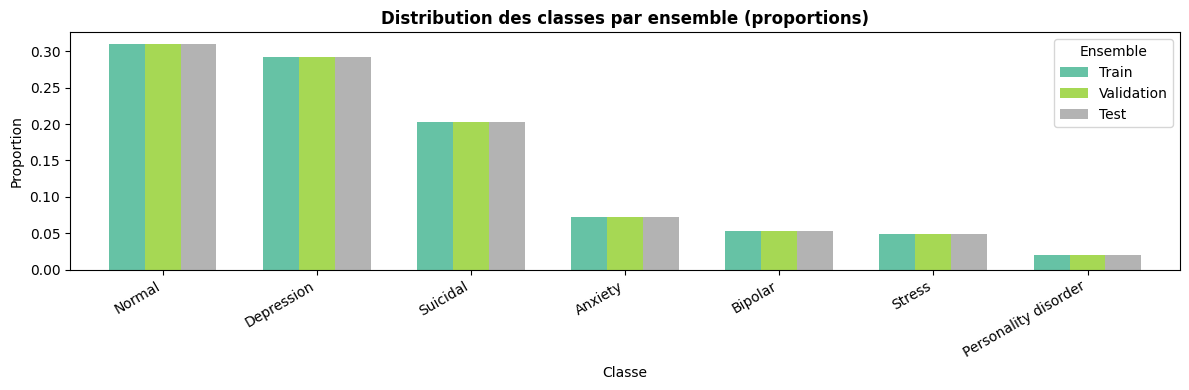

In [ ]:
dist = pd.DataFrame({
    'Train'      : y_train.value_counts(normalize=True),
    'Validation' : y_val.value_counts(normalize=True),
    'Test'       : y_test.value_counts(normalize=True),
}).fillna(0)

ax = dist.plot(kind='bar', figsize=(12, 4), colormap='Set2', width=0.7)
ax.set_title('Distribution des classes par ensemble (proportions)', fontweight='bold')
ax.set_xlabel('Classe')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Ensemble')
plt.tight_layout()
plt.show()

### 3.3 Préambule tokenisation

- **Punkt** : modèle pré-entraîné de NLTK qui segmente le texte en mots tout en gérant les abréviations et la ponctuation (.,!,?).
Il gère aussi les abréviations (ex. `Dr.Smith` ne sera pas séparé en `Dr` puis `.` puis `Smith`)
- **Stop words** : mots très fréquents sans valeur sémantique (`the`, `is`, `and`…) qui sont retirés pour réduire le bruit.
- **Porter Stemmer** : algorithme qui réduit chaque mot à sa racine (`running` → `run`, `people` → `peopl`). Les formes produites ne sont pas toujours des mots réels, c'est un compromis connu.

#### 3.3.1 Fonction de tokenisation

La fonction `simple_tokenizer` applique en séquence :
1. **Tokenisation** : découpe la chaîne en liste de mots avec `word_tokenize`
2. **Filtrage des stop-words** : retire les mots sans valeur sémantique
3. **Stemming** : réduit chaque mot à sa racine avec le Porter Stemmer

L'exemple en fin de cellule (`"i.e., running faster..."`) permet de tester le comportement sur une phrase contenant une abréviation et une majuscule.

In [ ]:
# Splitting text documents into tokens
import nltk 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [ ]:
# Download required NLTK data
nltk.download('punkt_tab')      # For punctuations used in word_tokenize 
nltk.download('stopwords')      # For stopword list

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/pc_v_maison/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/pc_v_maison/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def simple_tokenizer(text):
    stop_words = set(stopwords.words('english'))    # Define stopwords (English)
    stemmer = PorterStemmer()                       # Initialize the stemmer
    tokens = word_tokenize(text)                    # Tokenize the text   
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words] # Remove stopwords   
    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]             # Apply stemming
    return stemmed_tokens

# Example Usage
text = "i.e., running faster makes you stronger Mrs. Williams!"
print(simple_tokenizer(text))

['i.e.', ',', 'run', 'faster', 'make', 'stronger', 'mrs.', 'william', '!']


#### 3.3.2 Application de la tokenisation

La fonction `simple_tokenizer` est appliquée à chaque énoncé des ensembles train et test via `.apply()`. Chaque texte est ainsi transformé en une **liste de tokens** (racines de mots filtrés). Ces listes seront ensuite converties en vecteurs numériques par les vectoriseurs.

> **Attention**: Le temp d'exécution estimé peut aller de 1min à 2min30 !

In [ ]:
# Application of tokenizer
X_train_tokens = X_train.apply(simple_tokenizer)
X_val_tokens   = X_val.apply(simple_tokenizer)
X_test_tokens  = X_test.apply(simple_tokenizer)

#### 3.3.3 Tokenisation du dataset complet

La tokenisation est également appliquée sur `X` entier (train + test confondus). Cette version `X_full` sera utilisée plus tard pour la vectorisation TF-IDF complète, notamment dans le contexte du déploiement sur le dataset principal (`train.csv`).

In [ ]:
X_full=X.apply(simple_tokenizer)

#### 3.3.4. Aperçu des tokens

Affiche les 5 premières lignes tokenisées. Chaque cellule contient une liste de racines de mots. On peut y observer les effets du Porter Stemmer : `people` → `peopl`, `jealous` → `jealou`, etc. C'est le comportement attendu (voir discussion dans le notebook).

In [ ]:
# View a few tokenised statements
X_train_tokens.head()

22977                                       [lemau, right]
22034    [think, peopl, see, think, worst, hate, presen...
5223     [stress, leav, anyon, ever, success, take, fml...
10113    [safe, sane, sober, check, good, support, netw...
22176    [well, coupl, month, recent, got, hit, anoth, ...
Name: statement, dtype: object

---
### 3.4. Bag-of-Words (BoW)

#### 3.4.1 Vectorisation BoW

Le **Bag-of-Words** crée une matrice où chaque ligne est un document et chaque colonne est un mot du vocabulaire. La valeur d'une cellule est le **nombre d'occurrences** du mot dans le document.

- `fit_transform` sur le train : construit le vocabulaire **et** transforme les données
- `transform` sur le test : applique le **même vocabulaire** sans le reconstruire (règle fondamentale pour éviter le data leakage)

Les tokens (listes) sont reconvertis en chaînes (`' '.join(x)`) car `CountVectorizer` attend des strings.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initializing a vectoriser
bow_vectorizer = CountVectorizer()

# Fitting to the bow-vectorizer — sur le train uniquement
X_train_bow = bow_vectorizer.fit_transform(X_train_tokens.apply(lambda x: ' '.join(x)))
X_val_bow   = bow_vectorizer.transform(X_val_tokens.apply(lambda x: ' '.join(x)))
X_test_bow  = bow_vectorizer.transform(X_test_tokens.apply(lambda x: ' '.join(x)))

#### 3.4.2. Aperçu du vocabulaire BoW

Affiche un extrait du vocabulaire appris par le `CountVectorizer` (tokens de rang 2000 à 2080). Permet de vérifier que les termes stockés sont bien des racines issues du stemming, et non des mots bruts.

In [ ]:
# Show some of the vocabulary words
bow_vectorizer.get_feature_names_out()[2000:2080]  

array(['alamin', 'alan', 'alanin', 'alarm', 'alarmingli', 'alaska',
       'albanian', 'albeit', 'albert', 'alberta', 'albertson', 'album',
       'albumin', 'alc', 'alcahol', 'alcançar', 'alcapa', 'alchemist',
       'alchi', 'alchoh', 'alchohol', 'alchool', 'alco', 'alcohol',
       'alcoholi', 'alcol', 'alcoohol', 'alcool', 'ale', 'aleay', 'alec',
       'alejandralei', 'alement', 'alergi', 'alert', 'alessandrod',
       'alesso', 'alev', 'alevel', 'alex', 'alexa', 'alexandernl',
       'alexfost', 'alexlobaloba', 'alexrussin', 'alfredo', 'alg',
       'algebra', 'algn', 'algo', 'algonquin', 'algorithm', 'alguna',
       'alguno', 'alguém', 'alhaji', 'alhamdulilah', 'alhamdulillaaah',
       'alhamdulillah', 'alhasani', 'alhogol', 'ali', 'alia', 'alic',
       'aliceeu', 'aliceverheij', 'alielayu', 'alien', 'align', 'alik',
       'alimoni', 'alimwomba', 'alissa', 'alist', 'alittl', 'aliv',
       'alivei', 'aliveim', 'alivesomewher', 'alivesorri'], dtype=object)

#### 3.4.3 Dimensions de la matrice BoW

`X_train_bow.shape` retourne `(n_documents, n_features)` — le nombre de documents d'entraînement et la taille du vocabulaire. La matrice est **creuse** (sparse) : la plupart des cellules valent 0 car chaque document n'utilise qu'une infime fraction du vocabulaire total.

In [ ]:
# View the dimensions of the BoW matrix and a small portion of its data
print(X_train_bow.shape)  # (num_samples: documents, num_features: unique tokens)
print(X_train_bow[:5])    # Shows first 5 rows (sparse format: only non-zero elements)

(31579, 31180)
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 110 stored elements and shape (5, 31180)>
  Coords	Values
  (0, 16090)	1
  (0, 23209)	1
  (1, 27344)	2
  (1, 20699)	1
  (1, 24119)	1
  (1, 30466)	1
  (1, 12582)	1
  (1, 21596)	1
  (1, 9428)	1
  (1, 13675)	1
  (1, 9870)	1
  (1, 16953)	1
  (1, 29051)	1
  (2, 26095)	2
  (2, 16035)	3
  (2, 2620)	1
  (2, 9716)	1
  (2, 26256)	1
  (2, 26764)	1
  (2, 10756)	1
  (2, 21735)	1
  (2, 16272)	1
  (2, 23089)	1
  (2, 21637)	1
  (2, 9269)	1
  :	:
  (4, 27881)	1
  (4, 29960)	1
  (4, 6737)	1
  (4, 18137)	1
  (4, 22576)	1
  (4, 11922)	1
  (4, 13055)	1
  (4, 2496)	1
  (4, 29833)	1
  (4, 7675)	1
  (4, 10563)	1
  (4, 1411)	1
  (4, 20787)	1
  (4, 13532)	2
  (4, 9098)	1
  (4, 9343)	1
  (4, 5252)	2
  (4, 9391)	1
  (4, 27620)	1
  (4, 12826)	1
  (4, 18256)	1
  (4, 3628)	1
  (4, 18831)	1
  (4, 22510)	1
  (4, 26140)	1


### 3.5 TF-IDF
#### 3.5.1 Vectorisation TF-IDF

Le **TF-IDF** (Term Frequency - Inverse Document Frequency) améliore le BoW en pondérant les mots : un mot fréquent dans un document mais rare dans le corpus global reçoit un score élevé, et inversement.

Paramètres utilisés :
- `ngram_range=(1, 2)` : prend en compte les **unigrammes** (mots seuls) et les **bigrammes** (paires de mots consécutifs)
- `max_df=0.8` : ignore les mots présents dans plus de 80% des documents (trop communs)
- `min_df=5` : ignore les mots présents dans moins de 5 documents (trop rares)

Même logique que BoW : `fit_transform` sur train uniquement, `transform` sur test et full.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Define TfidfVectorizer with n-gram range
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.8, min_df=5)

# Apply TfidfVectorizer — fit sur le train uniquement
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_tokens.apply(lambda x: ' '.join(x)))
X_val_tfidf   = tfidf_vectorizer.transform(X_val_tokens.apply(lambda x: ' '.join(x)))
X_test_tfidf  = tfidf_vectorizer.transform(X_test_tokens.apply(lambda x: ' '.join(x)))
x_full_tfidf  = tfidf_vectorizer.transform(X_full.apply(lambda x: ' '.join(x)))

#### 3.5.2 Aperçu des features TF-IDF

Affiche un extrait des features apprises par le `TfidfVectorizer`. On peut y observer des **bigrammes** (ex: `feel anxious`, `mental health`) en plus des unigrammes, ce qui enrichit la représentation sémantique par rapport au BoW simple.

In [ ]:
# View Feature Names (Words or N-grams)
print(tfidf_vectorizer.get_feature_names_out()[20100:20150])

['goal like' 'goal motiv' 'goal plan' 'goal seem' 'goal set' 'goal tri'
 'goal want' 'goal weight' 'god' 'god alway' 'god aw' 'god bless'
 'god creat' 'god damn' 'god exist' 'god feel' 'god forbid' 'god forgiv'
 'god forsaken' 'god fuck' 'god get' 'god given' 'god go' 'god god'
 'god hate' 'god help' 'god hope' 'god kill' 'god know' 'god let'
 'god live' 'god love' 'god make' 'god pleas' 'god punish' 'god realli'
 'god sake' 'god someth' 'god still' 'god take' 'god tell' 'god test'
 'god think' 'god tri' 'god want' 'god wish' 'god would' 'goddamn' 'goe'
 'goe away']


#### 3.5.3 Dimensions de la matrice TF-IDF

Vérifie la forme de la matrice TF-IDF et affiche les scores non-nuls des 3 premiers documents. Les valeurs sont des **flottants entre 0 et 1** (contrairement au BoW qui sont des entiers), car TF-IDF normalise les fréquences.

In [ ]:
# See the dimensions of the BoW matrix and a small portion of its data
print(X_train_tfidf.shape) # (num_samples: documents, num_features: unique n-grams)
print(X_train_tfidf[:3])   # Shows nonzero TF-IDF scores in the first 3 documents

(31579, 56067)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38 stored elements and shape (3, 56067)>
  Coords	Values
  (0, 40211)	1.0
  (1, 48261)	0.20868377649866512
  (1, 36143)	0.10948612641115503
  (1, 41579)	0.12591102104213575
  (1, 54877)	0.18582410832909743
  (1, 21809)	0.13724233450912454
  (1, 37745)	0.2905804861431099
  (1, 13657)	0.19626631333670994
  (1, 23905)	0.17832970452564795
  (1, 15081)	0.1776616948619775
  (1, 30144)	0.10762765337893847
  (1, 51463)	0.21556316543361637
  (1, 48520)	0.28031202631998314
  (1, 36413)	0.2816972103052587
  (1, 41775)	0.33977362819199974
  (1, 48657)	0.32801922227503
  (1, 15107)	0.3700884567824035
  (1, 30379)	0.33605661100387485
  (2, 45487)	0.22261162699359427
  (2, 26778)	0.32388603023517093
  (2, 3120)	0.08478777652819298
  (2, 14311)	0.09614251300906855
  (2, 45980)	0.14618361969506102
  (2, 46753)	0.0832005265513883
  (2, 17364)	0.23403379913343939
  (2, 38073)	0.1537127488066804
  (2, 27675)	0.05659581631374521
 

### 3.6 Word2Vec

#### 3.6.1 Présentation

Le **Word2Vec** est un modèle de word embedding entraîné sur le corpus lui-même. Contrairement à BoW et TF-IDF qui représentent les textes par des comptages, Word2Vec apprend des **vecteurs denses** qui capturent le sens des mots à partir de leur contexte : deux mots apparaissant dans des contextes similaires auront des vecteurs proches dans l'espace vectoriel.

| | BoW | TF-IDF | Word2Vec |
|---|---|---|---|
| Type | Comptage | Fréquence pondérée | Vecteur dense |
| Dimension | Grande (vocabulaire entier) | Grande (vocabulaire entier) | Fixe et compacte (ex. 100) |
| Sens | ❌ | ❌ | ✅ |
| Valeurs négatives | ❌ | ❌ | ✅ |
| Compatible MultinomialNB | ✅ | ✅ | ❌ |
| Compatible K-Means | ✅ (après SVD) | ✅ (après SVD) | ✅ (direct) |

> 💡 Word2Vec est implémenté via la bibliothèque `gensim`. Le modèle est entraîné **uniquement sur `X_train_tokens`** pour éviter tout data leakage.


#### 3.6.2 Entraînement du modèle Word2Vec

Le modèle est entraîné sur les tokens de l'ensemble d'entraînement uniquement. Les paramètres utilisés :

| Paramètre | Valeur | Rôle |
|---|---|---|
| `vector_size` | `100` | Dimension des vecteurs de mots |
| `window` | `5` | Taille de la fenêtre de contexte (mots voisins pris en compte) |
| `min_count` | `2` | Ignorer les mots apparaissant moins de 2 fois |
| `workers` | `4` | Nombre de threads parallèles |
| `seed` | `42` | Reproductibilité |


In [ ]:
from gensim.models import Word2Vec

# Entraînement sur X_train_tokens uniquement (pas de data leakage)
w2v_model = Word2Vec(
    sentences=X_train_tokens.tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

print(f"Taille du vocabulaire Word2Vec : {len(w2v_model.wv)}")


Taille du vocabulaire Word2Vec : 14951


#### 3.6.3 Vérification sémantique

On vérifie que le modèle a bien appris des relations sémantiques en affichant les mots les plus proches de termes liés à la santé mentale. Dans un corpus de conversations patient-thérapeute, on s'attend à voir des regroupements cohérents autour de *anxiety*, *depression*, *stress*, etc.


In [ ]:
# Vérification : mots les plus proches de termes de santé mentale
for term in ["anxiety", "depression", "stress"]:
    if term in w2v_model.wv:
        similar = w2v_model.wv.most_similar(term, topn=5)
        print(f"\nMots proches de '{term}' :")
        for word, score in similar:
            print(f"  {word:20s} {score:.4f}")



Mots proches de 'stress' :
  manag                0.6286
  burnout              0.6073
  overwhelm            0.6056
  anxiou               0.5801
  jeprod               0.5797


#### 3.6.4 Vectorisation des textes par moyenne

Word2Vec produit un vecteur par **mot**. Pour représenter un **texte entier**, on calcule la **moyenne** de tous les vecteurs de mots qu'il contient. Les tokens absents du vocabulaire sont ignorés. Si aucun token n'est connu (texte vide après filtrage), on retourne un vecteur de zéros.

> 💡 **Pourquoi la moyenne ?** C'est la méthode la plus simple et elle fonctionne bien en pratique. Elle préserve la direction sémantique globale du texte dans l'espace vectoriel.


In [ ]:
import numpy as np
from sklearn.preprocessing import normalize

def text_to_vector(tokens, model):
    """Moyenne des vecteurs Word2Vec des tokens présents dans le vocabulaire."""
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Application sur les trois ensembles et le corpus complet
X_train_w2v = np.array([text_to_vector(tokens, w2v_model) for tokens in X_train_tokens])
X_val_w2v   = np.array([text_to_vector(tokens, w2v_model) for tokens in X_val_tokens])
X_test_w2v  = np.array([text_to_vector(tokens, w2v_model) for tokens in X_test_tokens])
X_full_w2v  = np.array([text_to_vector(tokens, w2v_model) for tokens in X_full])

print(f"Dimensions Word2Vec — Train : {X_train_w2v.shape} | Val : {X_val_w2v.shape} | Test : {X_test_w2v.shape}")


Dimensions Word2Vec — Train : (31579, 100) | Val : (10526, 100) | Test : (10527, 100)


#### 3.6.5 Normalisation L2

Les vecteurs Word2Vec sont normalisés pour que K-Means utilise une distance cosinus implicite, cohérente avec la nature sémantique des embeddings.

> 💡 Contrairement à TF-IDF, **aucune réduction SVD n'est nécessaire** : Word2Vec produit déjà des vecteurs denses de 100 dimensions, directement exploitables par K-Means.


In [ ]:
# Normalisation L2 — pas besoin de SVD contrairement à TF-IDF
X_train_w2v_norm = normalize(X_train_w2v, norm='l2')
X_val_w2v_norm   = normalize(X_val_w2v,   norm='l2')
X_test_w2v_norm  = normalize(X_test_w2v,  norm='l2')
X_full_w2v_norm  = normalize(X_full_w2v,  norm='l2')

print(f"Normalisation OK — Train : {X_train_w2v_norm.shape}")

Normalisation OK — Train : (31579, 100)


---
# **Fin de la partie commune ICI**

---

# 🔀 À partir d'ici : travail individuel

La partie commune est terminée. Vous disposez maintenant des variables suivantes, prêtes à l'emploi :

| Variable | Description |
|---|---|
| `X_train_bow`, `X_val_bow`, `X_test_bow` | Matrices Bag-of-Words (train / val / test) |
| `X_train_tfidf`, `X_val_tfidf`, `X_test_tfidf` | Matrices TF-IDF (train / val / test) |
| `X_full`, `x_full_tfidf` | Dataset complet tokenisé / vectorisé TF-IDF (pour le déploiement final) |
| `X_train_w2v_norm`, `X_val_w2v_norm`, `X_test_w2v_norm` | Matrices Word2Vec normalisées (train / val / test) |
| `X_full_w2v_norm` | Dataset complet vectorisé Word2Vec normalisé (pour le déploiement final) |
| `w2v_model` | Modèle Word2Vec entraîné (à utiliser avec `text_to_vector` pour de nouveaux textes) |
| `y_train`, `y_val`, `y_test` | Étiquettes de sentiment correspondantes |

Le notebook se divise maintenant en **deux parties indépendantes** selon votre groupe :

- 🟦 **Partie A — Méthode supervisée (Naive Bayes)** → Groupe : Diogo, Ulysse, Logan
- 🟩 **Partie B — Méthode non-supervisée (K-Means + Word2Vec)** → Groupe : Emin, Victor

Travaillez uniquement la partie qui vous correspond. Les deux parties aboutissent à une **annotation automatique de `train.csv`** qui sera transmise au Groupe 2.


---

# 🟩 Partie B — Méthode non-supervisée : K-Means + Word2Vec

> **Objectif** : Regrouper automatiquement les textes en clusters en utilisant des représentations **Word2Vec**, puis comparer ces clusters aux catégories réelles, évaluer la qualité du regroupement, et annoter `train.csv` avec le meilleur modèle.

Cette partie suit le pipeline suivant :

```
Entraînement Word2Vec → Vectorisation par moyenne → Normalisation → Sélection de k → Entraînement K-Means → Mapping cluster→label → Évaluation → Déploiement
```

## Pourquoi Word2Vec plutôt que BoW ?

| | BoW | Word2Vec |
|---|---|---|
| Représentation | Comptage de mots | Vecteur dense (contexte sémantique) |
| Dimension | Très grande (vocabulaire entier) | Fixe et compacte (ex. 100-300 dims) |
| Sens | Aucun | Mots proches = vecteurs proches |
| Exemple | "anxious" et "worried" → colonnes indépendantes | "anxious" et "worried" → vecteurs proches |
| Besoin de SVD ? | ✅ Oui (réduction nécessaire) | ❌ Non (déjà dense et compact) |

> 💡 Word2Vec est particulièrement adapté à notre corpus de santé mentale : des termes comme *depression*, *sadness*, *hopeless* seront naturellement regroupés dans l'espace vectoriel, ce qui aide K-Means à former des clusters thématiquement cohérents.


## B.1 — Réduction dimensionnelle et normalisation

Les matrices TF-IDF et BoW sont de très grande dimension (des dizaines de milliers de colonnes). K-Means fonctionne mieux dans un espace réduit.

**Ce que vous devez faire :**

1. Appliquer une **réduction dimensionnelle** avec `TruncatedSVD` (de `sklearn.decomposition`) :
   - Choisir `n_components=100` (ou moins si la matrice est plus petite)
   - **Important** : faire le `.fit_transform` sur `X_train_tfidf` uniquement, puis `.transform` sur `X_val_tfidf` et `X_test_tfidf`
2. **Normaliser** les matrices résultantes avec `normalize(..., norm='l2')` (de `sklearn.preprocessing`) pour que K-Means utilise une distance cosinus implicite

> 💡 **Pourquoi SVD ?** TF-IDF produit des matrices creuses (sparse) de très haute dimension. SVD compresse l'information en conservant les directions de variance maximale — similaire à une PCA, mais compatible avec les matrices creuses.

> ⚠️ Ne jamais `.fit` le SVD sur la validation ou le test. Appliquer uniquement `.transform`.


In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

svd = TruncatedSVD(n_components=100, random_state=42)
X_train_tfidf_svd = svd.fit_transform(X_train_tfidf)
X_val_tfidf_svd = svd.transform(X_val_tfidf)
X_test_tfidf_svd = svd.transform(X_test_tfidf)

X_train_tfidf_norm = normalize(X_train_tfidf_svd, norm='l2')
X_val_tfidf_norm = normalize(X_val_tfidf_svd, norm='l2')
X_test_tfidf_norm = normalize(X_test_tfidf_svd, norm='l2')

X_train_w2v_norm = normalize(X_train_w2v, norm='l2')
X_val_w2v_norm = normalize(X_val_w2v, norm='l2')
X_test_w2v_norm = normalize(X_test_w2v, norm='l2')

## B.1 — Sélection du nombre de clusters `k`

K-Means nécessite de choisir `k` à l'avance. On utilise deux critères complémentaires évalués **sur la validation** :

**Ce que vous devez faire :**

1. Tester des valeurs de `k` allant de 2 à 15
2. Pour chaque `k` :
   - Entraîner un `MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)` sur `X_train_w2v_norm`
   - Prédire les clusters sur `X_val_w2v_norm` avec `.predict(...)`
   - Calculer :
     - **WCSS** (inertie, `.inertia_`) — méthode du coude
     - **Score silhouette cosinus** avec `silhouette_score(..., metric='cosine', sample_size=2000, random_state=42)`
3. Tracer deux graphiques côte à côte : WCSS et silhouette en fonction de k
4. Retenir le `k` qui **maximise la silhouette** sur la validation → `best_k`
5. Appliquer un plancher : `best_k = max(best_k, y_train.nunique())`

> 💡 Avec Word2Vec, les clusters peuvent être plus naturels qu'avec TF-IDF car l'espace vectoriel est sémantiquement structuré — des mots comme *anxiety* et *worry* sont déjà proches dans cet espace.

> 💡 `silhouette_score` peut être lent sur grands datasets — utilisez `sample_size=2000` pour le limiter.


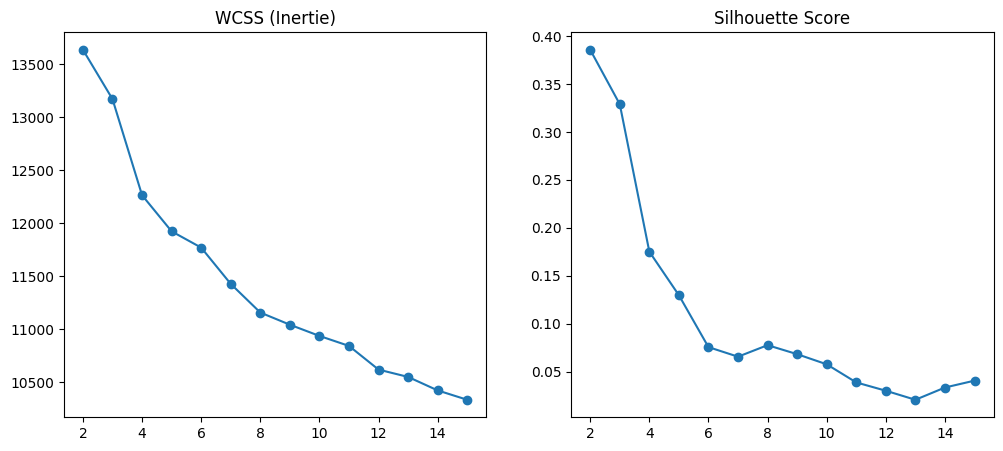

7


In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 16)
wcss = []
silhouettes = []

for k in k_values:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)
    kmeans.fit(X_train_w2v_norm)
    preds = kmeans.predict(X_val_w2v_norm)
    
    wcss.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_val_w2v_norm, preds, metric='cosine', sample_size=2000, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(k_values, wcss, marker='o')
ax1.set_title('WCSS (Inertie)')
ax2.plot(k_values, silhouettes, marker='o')
ax2.set_title('Silhouette Score')
plt.show()

best_k = k_values[np.argmax(silhouettes)]
best_k = max(best_k, y_train.nunique())
print(best_k)

## B.2 — Entraînement final et mapping cluster → label

**Dans un premier temps, qu'est ce que le *Mapping cluster* ?**
C'est la passerelle entre le monde non-supervisé (des numéros de clusters) et le monde supervisé (des étiquettes de sentiments).  

Initialement, K-Means ne connaît pas les étiquettes. Il produit des clusters numérotés 0,1,2,... Il ne sait pas que le cluster 2 correspond à "*Anxiety*" ou que le cluster 0 corresponde à "*Depression*". Il a juste regroupé des textes qui se ressemblent.  
Pour évaluer et déployer le modèle, on a besoin de convertir ces numéros en vraies étiquettes.

**La solution: le vote majoritaire**
On regarde, pour chaque cluster, quelles étiquettes réelles (`y_train`) contient la majorité de ses membres.

Prenons un exemple simplifié avec 3 clusters et 3 classes:
| Clusters | Sentiments | Majorité | Pureté(%) |
|-|-|-|-|
| 0 | [Anxiety, Anxiety, Depression, Anxiety] | "Anxiety" | 75 |
| 1 | [Depression, Depression, Normal, Depression] | "Depression" | 75 |
| 2 | [Normal, Anxiety, Normal, Normal] | "Normal" | 75 |

On contruit alors le dictionnaire:
```python
cluster_to_label = {0: "Anxiety", 1: "Depression", 2: "Normal"}
```

Et la prédiction devient triviale : pour un nouveau texte assigné au cluster 1, on retourne "*Depression*".

**Le problème du conflit:**
Imaginez maintenant que deux clusters veulent la même étiquette :
| Clusters | Sentiments | Majorité | Pureté(%) |
|-|-|-|-|
| 0 | [Anxiety, Anxiety, Anxiety, Depression] | "Anxiety" | 75 |
| 1 | [Anxiety, Anxiety, Normal, Normal] | "Anxiety" | 50 |
| 2 | [Depression, Depression, Depression, Normal] | "Depression" | 75 |

Si on assignait naïvement, les clusters 0 et 1 prendraient tous les deux "*Anxiety*", et personne ne représenterait "Normal". La stratégie gloutonne règle ça :
   1. On trie les clusters par pureté décroissante
   2. Le cluster 0 (75%) prend "*Anxiety*" en premier — il est réservé
   3. Le cluster 1 (50%) voulait "*Anxiety*" mais c'est pris → il prend sa 2e étiquette majoritaire, "Normal"
   4. Le cluster 2 prend "*Depression*"

Ce que ça mesure : **la pureté**.  
La pureté d'un cluster = **proportion de son label majoritaire parmi tous ses membres**.

Pureté de 1.0 → cluster parfaitement homogène, tous les textes parlent du même sentiment  
Pureté de 0.5 → moitié des textes ont le bon label, l'autre moitié est du bruit

Une pureté globale élevée signifie que K-Means a réussi à isoler des groupes thématiquement cohérents, ce qui est encourageant pour la santé mentale où les thèmes sont souvent bien distincts lexicalement (mots liés à l'anxiété vs. à la dépression vs. au stress).

**Ce que vous devez faire :**

1. Entraîner un `MiniBatchKMeans` final avec `best_k` sur `X_train_w2v_norm`
2. Récupérer les identifiants de clusters sur le train avec `.fit_predict(...)`
3. Construire le dictionnaire `cluster_to_label` par **vote majoritaire** :
   - Pour chaque cluster `c`, regarder les étiquettes réelles (`y_train`) de ses membres
   - Lui attribuer l'étiquette la plus fréquente
   - Si deux clusters veulent la même étiquette → stratégie gloutonne : le cluster de plus haute pureté garde l'étiquette, l'autre prend sa deuxième étiquette majoritaire

4. Afficher le mapping final : pour chaque cluster → label attribué + pureté

> 💡 La **pureté** d'un cluster = proportion de son label majoritaire parmi tous ses membres. Un cluster de pureté 1.0 est parfaitement homogène (tous les textes ont le même sentiment).


In [ ]:
kmeans_final = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=1000, n_init=10)
train_clusters = kmeans_final.fit_predict(X_train_w2v_norm)

cluster_purity = []
for c in range(best_k):
    idx = np.where(train_clusters == c)[0]
    if len(idx) > 0:
        labels = y_train.iloc[idx]
        majority_label = labels.mode()[0]
        purity = (labels == majority_label).sum() / len(idx)
        counts = labels.value_counts()
        cluster_purity.append({'cluster': c, 'purity': purity, 'counts': counts})

cluster_purity.sort(key=lambda x: x['purity'], reverse=True)

cluster_to_label = {}
assigned_labels = set()

for c_info in cluster_purity:
    c = c_info['cluster']
    for label in c_info['counts'].index:
        if label not in assigned_labels:
            cluster_to_label[c] = label
            assigned_labels.add(label)
            break
    if c not in cluster_to_label:
        cluster_to_label[c] = c_info['counts'].index[0]

for c, label in cluster_to_label.items():
    pur = next(item['purity'] for item in cluster_purity if item['cluster'] == c)
    print(f"Cluster {c} -> {label} (Pureté: {pur:.2f})")

Cluster 3 -> Normal (Pureté: 0.89)
Cluster 0 -> Suicidal (Pureté: 0.85)
Cluster 1 -> Depression (Pureté: 0.44)
Cluster 5 -> Stress (Pureté: 0.42)
Cluster 2 -> Bipolar (Pureté: 0.41)
Cluster 6 -> Anxiety (Pureté: 0.37)
Cluster 4 -> Personality disorder (Pureté: 0.28)


## B.3 — Évaluation quantitative

**Ce que vous devez faire :**

1. Prédire les clusters sur `X_test_w2v_norm`, puis convertir en étiquettes via `cluster_to_label`
2. Calculer les métriques suivantes :

| Métrique | Fonction | Ce qu'elle mesure |
|---|---|---|
| **Accuracy** | `accuracy_score` | Proportion de bonne classification après mapping |
| **Matrice de confusion** | `ConfusionMatrixDisplay` | Visualisation des erreurs par classe |
| **Purity globale** | (à coder manuellement) | Proportion de documents bien assignés |
| **ARI** | `adjusted_rand_score` | Accord clusters / vraies étiquettes, corrigé du hasard |

> 💡 **Formule de la purity globale** : pour chaque vrai label, trouver le cluster qui le contient le plus, sommer ces maximums et diviser par le nombre total de documents.

3. Interpréter : quelles classes sont bien séparées par Word2Vec ? Lesquelles sont confondues ?


> 💡 **Purity** : pour chaque vrai label, on trouve le cluster qui le contient le plus, puis on somme ces maximums et on divise par le total.

> 💡 **ARI** s'obtient avec `adjusted_rand_score(y_true, y_pred)` de `sklearn.metrics`. Il est plus fiable que la purity car il est insensible aux classes déséquilibrées.


Accuracy : 0.2489
Purity globale : 0.4853
ARI : 0.1304


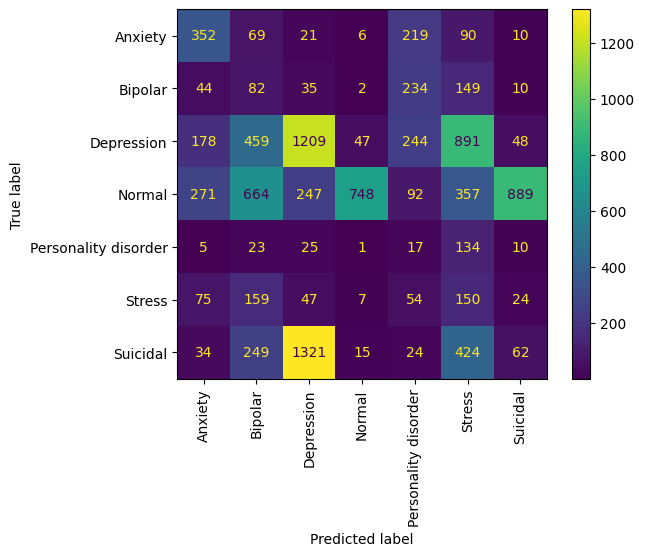

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, adjusted_rand_score

test_clusters = kmeans_final.predict(X_test_w2v_norm)
y_pred = [cluster_to_label[c] for c in test_clusters]

acc = accuracy_score(y_test, y_pred)
ari = adjusted_rand_score(y_test, test_clusters)

def get_global_purity(y_true, clusters):
    total = len(y_true)
    correct = 0
    for c in np.unique(clusters):
        idx = np.where(clusters == c)[0]
        if len(idx) > 0:
            correct += y_true.iloc[idx].value_counts().max()
    return correct / total

purity = get_global_purity(y_test, test_clusters)

print(f"Accuracy : {acc:.4f}")
print(f"Purity globale : {purity:.4f}")
print(f"ARI : {ari:.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation='vertical')
plt.show()

## B.4 — Comparaison TF-IDF vs Word2Vec pour K-Means

Vous disposez maintenant de deux approches de vectorisation pour K-Means. Comparez-les.

**Ce que vous devez faire :**

Construire un tableau comparatif (DataFrame pandas ou simple print) :

| Critère | K-Means + TF-IDF | K-Means + Word2Vec |
|---|---|---|
| Meilleur k retenu | ? | ? |
| Accuracy sur test | ? | ? |
| Purity globale | ? | ? |
| ARI | ? | ? |
| Besoin de SVD ? | Oui | Non |
| Dimension de l'espace | ~100 (après SVD) | 100 (natif) |

Rédiger une courte analyse :
- Quelle vectorisation donne de meilleurs clusters ? Pourquoi à votre avis ?
- Y a-t-il des classes mieux gérées par l'une ou l'autre méthode ?
- Quel modèle recommandez-vous pour l'annotation finale de `train.csv` ?

> 💡 Pour récupérer les métriques TF-IDF, vous pouvez re-lancer rapidement le pipeline K-Means sur `X_train_tfidf` / `X_val_tfidf` / `X_test_tfidf` (en refaisant SVD + normalisation), ou vous référer aux résultats notés lors des runs précédents.


In [ ]:
# B.4 — Votre code / analyse ici


## B.5 — Comparaison avec la méthode supervisée

Une fois les deux méthodes évaluées (supervisée par le Groupe 1, non-supervisée ici), il faut décider laquelle utiliser pour l'annotation finale.

**Ce que vous devez faire :**

Rédiger une courte analyse (dans cette cellule markdown ou dans une cellule code avec des `print`) comparant :

- L'accuracy respective des deux méthodes sur le test
- La nature des erreurs observées (quelles classes sont mal prédites dans chaque cas ?)
- Les avantages et limites de chaque approche dans ce contexte

> 💡 **Comment comparer supervisé et non-supervisé ?** C'est une vraie question méthodologique. La comparaison directe par accuracy est possible ici car le mapping cluster→label permet d'obtenir des prédictions dans le même espace. Cependant, le non-supervisé ne "voit" pas les labels pendant l'entraînement, donc une accuracy inférieure est attendue — ce n'est pas forcément un défaut, mais plutôt la contrepartie de l'absence d'annotation.

Conclure en indiquant quel modèle sera utilisé pour l'annotation de `train.csv`.


In [ ]:
# B.5 — Votre analyse ici (commentaires Python ou cellule markdown)


## B.6 — Déploiement sur le dataset principal (`train.csv`)

**Ce que vous devez faire :**

1. Charger `train.csv` dans un DataFrame `df_main`
2. Appliquer la même chaîne de prétraitement :
   - Nettoyage (`cleaner`)
   - Tokenisation (`simple_tokenizer`)
   - Vectorisation avec le **vectoriseur déjà fitté** (`.transform` uniquement, pas de nouveau `.fit`)
   - Réduction SVD avec le **SVD déjà fitté** (`.transform` uniquement)
   - Normalisation L2
3. Prédire les clusters avec le modèle K-Means final, puis convertir en étiquettes via `cluster_to_label`
4. Ajouter une colonne `predicted_sentiment` au DataFrame
5. Afficher les 10 premières lignes annotées
6. Sauvegarder le DataFrame annoté dans `train_with_sentiments_kmeans.csv`

> ⚠️ Toutes les transformations (SVD, vectoriseur) doivent avoir été fittées **uniquement sur le train de `combined_data.csv`**. Ne pas refaire de fit sur `train.csv`.


In [ ]:
df_main = pd.read_csv('../../data/train.csv').dropna(subset=['Response'])

df_main['cleaned_text'] = df_main['Response'].apply(cleaner)
df_main['tokens'] = df_main['cleaned_text'].apply(simple_tokenizer)

X_main_tfidf = tfidf_vectorizer.transform(df_main['cleaned_text'])
X_main_svd = svd.transform(X_main_tfidf)
X_main_norm = normalize(X_main_svd, norm='l2')

main_clusters = kmeans_final.predict(X_main_norm)

df_main['predicted_sentiment'] = [cluster_to_label[c] for c in main_clusters]

print(df_main[['Response', 'predicted_sentiment']].head(10))

df_main.to_csv('train_with_sentiments_kmeans.csv', index=False)

                                            Response predicted_sentiment
0  If everyone thinks you're worthless, then mayb...            Suicidal
1  Hello, and thank you for your question and see...              Normal
2  First thing I'd suggest is getting the sleep y...              Normal
3  Therapy is essential for those that are feelin...            Suicidal
4  I first want to let you know that you are not ...              Normal
5  Heck, sure thing, hun!Feelings of 'depression'...            Suicidal
6  You are exhibiting some specific traits of a p...              Normal
7  That is intense. Depression is a liar. Sometim...            Suicidal
8  It sounds like you may be putting yourself las...            Suicidal
9  It must be really difficult to experience what...            Suicidal


---

# 📋 Récapitulatif et transmission au Groupe 2

Une fois les deux parties terminées, mettre en commun les résultats :

| Étape | Groupe supervisé | Groupe non-supervisé |
|---|---|---|
| Meilleure accuracy (test) | ? | ? |
| Modèle retenu | Naive Bayes BoW ou TF-IDF | K-Means TF-IDF ou BoW |
| Fichier produit | `train_with_sentiments.csv` | `train_with_sentiments_kmeans.csv` |

**Décision finale** : le modèle avec la meilleure accuracy (ou justifiée par d'autres critères) est sélectionné pour fournir les annotations au Groupe 2.

Le fichier `train_with_sentiments.csv` (ou `_kmeans`) contenant la colonne `predicted_sentiment` est transmis au Groupe 2 pour le filtrage par sentiments dans le système Q&A.
